# The Impact of Air Pollution on Asthma: A Regression Analysis

In [1]:
!pip install pandas

In [2]:
!pip install seaborn

In [3]:
!pip install scikit-learn

In [101]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.5 MB 21.8 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 20.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 

In [102]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import zscore
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


## Goal of the project
This project investigates the relationship between air pollution and asthma in the United States. To achieve this, data from the **US Environmental Protection Agency** (EPA) and the **Centers for Disease Control and Prevention** (CDCs) are combined and analyzed. Air quality indicators are merged with health data at the state and county levels, and exploratory data analysis is conducted to identify patterns. A linear regression model is then applied to examine the relationship between air pollution and asthma prevalence and hospital visits.

## Asthma and air pollution, previous research
According to the Asthma and Allergy Foundation of America, air pollution can cause asthma and other lung diseases. It also worsens asthma symptoms and leads to increased hospital visits. People with asthma are more sensitive to small airborne particles, found in haze, smoke, soot, and airborne dust. Small airborne particles are called “particulate matter” or PM. The smallest particles (PM$_{2.5}$) are the most dangerous. In addition, irritating gases, such as ozone (O$_3$), nitrogen dioxide (NO$_2$), sulfur dioxide (SO$_2$), carbon monoxide (CO), and methane (CH$_4$), can also cause health issues.

The study [Impact of Air Pollution on Asthma Outcomes](https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/) found that indoor and outdoor pollution represents a major public health threat with a negative impact on asthma outcomes. It demonstrated that not only traffic-related air pollution a risk factor for asthma development in children, but so are NO$_2$ and secondhand smoke exposures. However, **a causal relation between air pollution and the development of adult asthma could not be clearly established**. The exposure to ourdoor pollutants (O$_3$, NO$_2$, SO$_2$, CO, PM) could induce asthma symptoms, exacerbations and hospitalizations.

The study [Associations among air pollution, asthma and lung function](https://www.nature.com/articles/s41598-025-88807-6) found that higher exposure to air pollutants such as PM$_{2.5}$, PM$_{10}$, and NO$_2$ is significantly associated with an increased likelihood of asthma in adults. It also showed that air pollution is linked to worse asthma outcomes, including more frequent wheezing and higher rates of hospitalization. The study concluded that air pollution is an important risk factor for both the occurrence and severity of asthma, although **causal relationships require further longitudinal cohort research**.

The study [Predicting Asthma Hospitalizations from Climate and Air Pollution Data](https://www.mdpi.com/2225-1154/13/2/23#B2-climate-13-00023) found that asthma hospitalizations can be predicted using a combination of air pollution and meteorological variables. Among the tested models, random forest performed best, particularly when past asthma data were included. Key factors influencing asthma hospitalizations include minimum temperature and SO$_2$ levels. The study showed that **combining environmental data with time-series information improves the prediction and monitoring of asthma outcomes**.


## The datasets and preprocessing

#### 1) EPA dataset
EPA measures key air pollutants, including PM$_{2.5}$, O$_3$, NO$_2$, in the US daily. These measurements are converted into the **Air Quality Index (AQI)**. For each day, an AQI value is calculated for each pollutant, and the highest of these values is selected as the overall AQI. This means that the AQI reflects the pollutant posing the greatest health risk on that day, rather than an average of all pollutants. Days are then classified into health categories, and the number of days in each category is counted for each county over the year.


![AQI Scale](images/AQI_scale.jpg)

The dataset also includes data on median AQI, 90th percentile AQI and Max AQI. Median AQI reflects typical air quality conditions, while the 90th-percentile AQI captures frequent high-pollution exposure. Max AQI represents extreme pollution events. The dataset also shows how many days in the year a specific pollutant was the main driver of AQI, which tells us what type of pollution people are exposed to, not just how much.

For our investigation we will work with data for eight years, 2017-2024.

In [5]:
# Loading the datasets
files = glob.glob("data/EPA_annual_aqi_by_county/annual_aqi_by_county_*.csv")
epa_list = [pd.read_csv(file) for file in files]
#Check if all are loaded
len(epa_list)

8

In [6]:
# Combining the datasets
epa = pd.concat(epa_list, ignore_index = True)
epa.shape

(8075, 18)

In [7]:
epa.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,Baldwin,2017,270,224,45,1,0,0,0,108,56,39,0,0,188,82,0
1,Alabama,Clay,2017,118,76,42,0,0,0,0,69,57,40,0,0,0,118,0
2,Alabama,Colbert,2017,283,244,39,0,0,0,0,67,53,39,0,0,202,81,0
3,Alabama,DeKalb,2017,359,305,54,0,0,0,0,80,54,40,0,0,290,69,0
4,Alabama,Elmore,2017,226,221,5,0,0,0,0,58,45,35,0,0,226,0,0


We can see that we do not have data for each day of the year. The Days with AQI column shows that. We will have to ignore that missing data and hope that the avarage yearly values will be close tothe truth.

In [68]:
distribution_stats = epa_state['Days with AQI'].describe()
print(distribution_stats)

count    432.000000
mean     317.939458
std       48.586590
min       46.500000
25%      298.115079
50%      329.068182
75%      351.871976
max      366.000000
Name: Days with AQI, dtype: float64


In [69]:
low_data_states = epa_state[epa_state['Days with AQI'] < 100]
low_data_summary = low_data_states[['State', 'Year', 'Days with AQI']]
low_data_summary = low_data_summary.sort_values(by='Days with AQI')

print("--- States and Years with < 100 Days of AQI Data ---")
print(low_data_summary)

--- States and Years with < 100 Days of AQI Data ---
              State  Year  Days with AQI
384  Virgin Islands  2017      46.500000
385  Virgin Islands  2018      69.000000
389  Virgin Islands  2022      73.000000
387  Virgin Islands  2020      81.666667
388  Virgin Islands  2021      82.000000


It seems that only the Virgin Islands have for five the years under 100 days with data. We should keep in mind that we have less data for that state going forward.

In [8]:
# Checking if we have all years
epa["Year"].value_counts()

Year
2017    1029
2019    1023
2018    1021
2020    1006
2021    1005
2022    1003
2024     996
2023     992
Name: count, dtype: int64

In [9]:
# Checking for missing values
epa.isnull().sum()

State                                  0
County                                 0
Year                                   0
Days with AQI                          0
Good Days                              0
Moderate Days                          0
Unhealthy for Sensitive Groups Days    0
Unhealthy Days                         0
Very Unhealthy Days                    0
Hazardous Days                         0
Max AQI                                0
90th Percentile AQI                    0
Median AQI                             0
Days CO                                0
Days NO2                               0
Days Ozone                             0
Days PM2.5                             0
Days PM10                              0
dtype: int64

In [10]:
epa.info()

<class 'pandas.DataFrame'>
RangeIndex: 8075 entries, 0 to 8074
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   State                                8075 non-null   str  
 1   County                               8075 non-null   str  
 2   Year                                 8075 non-null   int64
 3   Days with AQI                        8075 non-null   int64
 4   Good Days                            8075 non-null   int64
 5   Moderate Days                        8075 non-null   int64
 6   Unhealthy for Sensitive Groups Days  8075 non-null   int64
 7   Unhealthy Days                       8075 non-null   int64
 8   Very Unhealthy Days                  8075 non-null   int64
 9   Hazardous Days                       8075 non-null   int64
 10  Max AQI                              8075 non-null   int64
 11  90th Percentile AQI                  8075 non-null   int64
 12  Med

Because we will be comparing the data with asthmm prevelance data on the state level we need to aggregate the air quality data, 

In [11]:
# Aggregate to state level
epa_state = (
    epa.groupby(["State", "Year"])
    .mean(numeric_only = True)
    .reset_index()
)

In [12]:
epa_state.shape

(432, 17)

In [13]:
epa_state.head()

,State,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,2017,286.444444,191.333333,94.222222,0.777778,0.055556,0.055556,0.0,106.888889,58.333333,42.888889,0.0,0.055556,133.722222,149.500000,3.166667
1,Alabama,2018,294.588235,197.882353,96.176471,0.411765,0.117647,0.000000,0.0,99.117647,58.176471,41.411765,0.0,0.058824,133.529412,160.823529,0.176471
2,Alabama,2019,290.235294,191.000000,98.235294,1.000000,0.000000,0.000000,0.0,89.882353,58.588235,43.470588,0.0,0.000000,137.352941,152.352941,0.529412
3,Alabama,2020,288.933333,201.666667,86.933333,0.333333,0.000000,0.000000,0.0,86.333333,55.333333,39.600000,0.0,0.000000,121.200000,167.466667,0.266667
4,Alabama,2021,294.800000,204.200000,89.933333,0.533333,0.133333,0.000000,0.0,92.733333,57.000000,40.533333,0.0,0.066667,120.666667,173.200000,0.866667


#### 2) CDC dataset on asthma prevalence - state resolution
The dataset comes from the Centers for Disease Control and Prevention Behavioral Risk Factor Surveillance System (BRFSS), a large national survey that collects health, demographic, and behavioral information from US adults. Each observation in the dataset represents an individual respondent, and the data will be aggregated to produce state-level health indicators. Asthma prevalence is measured using the CDC-derived variable _CASTHM1, which combines information on whether a respondent has ever been diagnosed with asthma and whether they currently have the condition. 

![CASTHM1 Variable](images/_CASTHM1.png)

The data is a bit messy and incomplete. For some of the years not all states were able to provide data. We will omit those states that do not have all years.

In [14]:
# Loading the datasets
files_cdc = glob.glob("data/CDC_asthma_prevelance_state/LLCP*.XPT")

cdc_list = [pd.read_sas(file, format = "xport") for file in files_cdc]

In [15]:
len(cdc_list)

8

Now lets filter the dataset to keep only valid asthma responses, _CASTHM1 = 1 (no current asthma) and _CASTHM1 = 2 (current asthma), removing all other values such as missing or unknown responses.

In [16]:
cdc_list = [df[["_STATE", "_CASTHM1"]] for df in cdc_list]
cdc_list[0].head()

,_STATE,_CASTHM1
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,2.0


In [17]:
cdc_list = [df[df["_CASTHM1"].isin([1, 2])] for df in cdc_list]
cdc_list[0]["_CASTHM1"].value_counts()

_CASTHM1
1.0    404548
2.0     42254
Name: count, dtype: int64

In [18]:
# Creating binary asthma variable
cdc_list = [
    df.assign(asthma=(df["_CASTHM1"] == 2).astype(int))
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,_CASTHM1,asthma
0,1.0,1.0,0
1,1.0,1.0,0
2,1.0,1.0,0
3,1.0,1.0,0
4,1.0,2.0,1


In [19]:
# Adding the year to each dataset
years = list(range(2017, 2024))  # adjust if needed

cdc_list = [
    df.assign(Year=year)
    for df, year in zip(cdc_list, years)
]
cdc_list[0].head()

,_STATE,_CASTHM1,asthma,Year
0,1.0,1.0,0,2017
1,1.0,1.0,0,2017
2,1.0,1.0,0,2017
3,1.0,1.0,0,2017
4,1.0,2.0,1,2017


In [20]:
# Calculating asthma prevalence
cdc_list = [
    df.groupby(["_STATE", "Year"])["asthma"]
      .mean()
      .reset_index()
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,Year,asthma
0,1.0,2017,0.110497
1,2.0,2017,0.080189
2,4.0,2017,0.101053
3,5.0,2017,0.093685
4,6.0,2017,0.087317


In [21]:
# Adding the names of the states
state_map = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia",
    12: "Florida", 13: "Georgia", 15: "Hawaii",
    16: "Idaho", 17: "Illinois", 18: "Indiana",
    19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota",
    39: "Ohio", 40: "Oklahoma", 41: "Oregon",
    42: "Pennsylvania", 44: "Rhode Island",
    45: "South Carolina", 46: "South Dakota",
    47: "Tennessee", 48: "Texas", 49: "Utah",
    50: "Vermont", 51: "Virginia", 53: "Washington",
    54: "West Virginia", 55: "Wisconsin", 56: "Wyoming"
}

cdc_list = [
    df.assign(State = df["_STATE"].map(state_map))
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,Year,asthma,State
0,1.0,2017,0.110497,Alabama
1,2.0,2017,0.080189,Alaska
2,4.0,2017,0.101053,Arizona
3,5.0,2017,0.093685,Arkansas
4,6.0,2017,0.087317,California


In [22]:
# Combining all datasets 
asthma_state = pd.concat(cdc_list, ignore_index = True)
asthma_state.head()

,_STATE,Year,asthma,State
0,1.0,2017,0.110497,Alabama
1,2.0,2017,0.080189,Alaska
2,4.0,2017,0.101053,Arizona
3,5.0,2017,0.093685,Arkansas
4,6.0,2017,0.087317,California


In [23]:
asthma_state = asthma_state[["State", "Year", "asthma"]]
asthma_state.head()

,State,Year,asthma
0,Alabama,2017,0.110497
1,Alaska,2017,0.080189
2,Arizona,2017,0.101053
3,Arkansas,2017,0.093685
4,California,2017,0.087317


In [24]:
#Checking for missing states
asthma_state.groupby("Year")["State"].nunique()

Year
2017    51
2018    51
2019    50
2020    51
2021    50
2022    51
2023    49
Name: State, dtype: int64

In [25]:
# Keeping only states that have data for all 7 years
complete_states = (
    asthma_state.groupby("State")["Year"]
    .nunique()
)

complete_states = complete_states[complete_states == asthma_state["Year"].nunique()].index

In [26]:
asthma_state = asthma_state[asthma_state["State"].isin(complete_states)]
asthma_state.groupby("Year")["State"].nunique()

Year
2017    47
2018    47
2019    47
2020    47
2021    47
2022    47
2023    47
Name: State, dtype: int64

In [27]:

all_states = set(pd.concat(cdc_list, ignore_index = True)["State"].unique())
removed_states = all_states - set(complete_states)

removed_states

{'Florida', 'Kentucky', 'New Jersey', 'Pennsylvania', nan}

In [28]:
# Saving the dataset
asthma_state.to_csv("data/asthma_prevelance_state_clean.csv", index = False)

#### 3) CDC dataset on asthma prevalence - county resolution
We will derive this dataset again from CDC data, as for our analysis, we will need the asthma prevelance values on the county level as well. This data is not available for all years, we have form 2018 to 2023.

In [29]:
files_places = glob.glob("data/CDV_asthma_prevalance_county/PLACES*.csv")
places_list = [pd.read_csv(file, low_memory = False) for file in files_places]

In [30]:
len(places_list)

6

In [31]:
places_list[0].head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,Latitude,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocatioin
0,2018,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,12.2,...,NaN,11.9,12.4,"327,167,434",NaN,PREVENT,ACCESS2,CrdPrv,Health Insurance,NaN
1,2018,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Age-adjusted prevalence,13.1,...,NaN,12.9,13.4,"327,167,434",NaN,PREVENT,ACCESS2,AgeAdjPrv,Health Insurance,NaN
2,2018,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults aged >=18 years,%,Crude prevalence,25.8,...,NaN,25.6,26.1,"327,167,434",NaN,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,NaN
3,2018,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults aged >=18 years,%,Age-adjusted prevalence,23.1,...,NaN,22.9,23.3,"327,167,434",NaN,HLTHOUT,ARTHRITIS,AgeAdjPrv,Arthritis,NaN
4,2018,US,United States,NaN,BRFSS,Unhealthy Behaviors,Binge drinking among adults aged >=18 years,%,Crude prevalence,16.4,...,NaN,16.2,16.7,"327,167,434",NaN,UNHBEH,BINGE,CrdPrv,Binge Drinking,NaN


In [32]:
places_list[0].columns

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Latitude', 'CategoryID', 'MeasureId', 'DataValueTypeID',
       'Short_Question_Text', 'Geolocatioin'],
      dtype='str')

In [33]:
places_list[0]["Measure"].unique()

<StringArray>
[                                                                                                                                'Current lack of health insurance among adults aged 18-64 years',
                                                                                                                                                         'Arthritis among adults aged >=18 years',
                                                                                                                                                    'Binge drinking among adults aged >=18 years',
                                                                                                                                               'High blood pressure among adults aged >=18 years',
                                                                                                                                'Visits to dentist or dental clinic among adults aged >=18 years',
           

In [34]:
# Searching for the asthma data
places_list[0][places_list[0]["Measure"].str.contains("asthma", case=False, na=False)]["Measure"].unique()

<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

In [35]:
for i, df in enumerate(places_list):
    asthma_measures = df[
        df["Measure"].str.contains("asthma", case=False, na=False)
    ]["Measure"].unique()
    
    print(f"Dataset {i}:")
    print(asthma_measures)
    print()

Dataset 0:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 1:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 2:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 3:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 4:
<StringArray>
['Current asthma among adults']
Length: 1, dtype: str

Dataset 5:
<StringArray>
['Current asthma among adults']
Length: 1, dtype: str



In [36]:
places_list = [
    df.assign(
        Measure=df["Measure"].replace({
            "Current asthma among adults aged >=18 years": "Current asthma among adults",
        })
    )
    for df in places_list
]

In [37]:
places_asthma_list = [
    df[df["Measure"] == "Current asthma among adults"]
    for df in places_list
]
places_asthma_list[0][["Year", "StateDesc", "LocationName", "Data_Value"]].head()

,Year,StateDesc,LocationName,Data_Value
15,2018,United States,NaN,9.2
16,2018,United States,NaN,9.1
86,2018,Alabama,Autauga,10.2
87,2018,Alabama,Autauga,10.2
141,2018,Alabama,Baldwin,9.5


The dataset includes national rows where StateDesc = United States and LocationName = NaN. We will remove those rows and keep only real county rows.

In [38]:
places_asthma_list = [
    df[df["LocationName"].notna()]
    for df in places_asthma_list
]
places_asthma_list[0][["Year", "StateDesc", "LocationName", "Data_Value"]].head()

,Year,StateDesc,LocationName,Data_Value
86,2018,Alabama,Autauga,10.2
87,2018,Alabama,Autauga,10.2
141,2018,Alabama,Baldwin,9.5
142,2018,Alabama,Baldwin,9.6
198,2018,Alabama,Barbour,11.6


In [39]:
# Combining the datasets and keeping what we need
places_asthma = pd.concat(places_asthma_list, ignore_index = True)
places_asthma = places_asthma[["Year", "StateDesc", "LocationName", "Data_Value"]]
places_asthma = places_asthma.rename(columns={
    "StateDesc": "State",
    "LocationName": "County",
    "Data_Value": "asthma"
})

In [40]:
places_asthma.to_csv("data/asthma_county_clean.csv", index = False)

#### 4) California county ED visits dataset
In our investigation, we also want to explore whether air quality affects asthma-rlated visit to emergency departmens (EDs). This datase contains counts and rates (per 10,000 residents) of asthma ED visits among Californians, from 2015 to 2023. Publicly available data is very scarce in this regard, only this dataset from California and the following from Minnesota could be uncovered. 

In [41]:
asthma_ED_Cal = pd.read_csv(
    "data/asthma-emergency-department-visit-rates-by-county-2015_2023.csv",
    encoding="latin-1"
)

In [42]:
asthma_ED_Cal.head()

,COUNTY,YEAR,STRATA,STRATA NAME,AGE GROUP,NUMBER OF ED VISITS,AGE-ADJUSTED ED VISIT RATE,COMMENT
0,California,2015,Total population,All ages,All ages,"191,904",50.4,NaN
1,Alameda,2015,Total population,All ages,All ages,"9,939",64.3,NaN
2,Alpine,2015,Total population,All ages,All ages,0,0.0,NaN
3,Amador,2015,Total population,All ages,All ages,196,58.4,NaN
4,Butte,2015,Total population,All ages,All ages,"1,044",50.2,NaN


In [43]:
asthma_ED_Cal["YEAR"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [44]:
asthma_ED_Cal["STRATA"].unique()

<StringArray>
['Total population', 'Child vs. adult', 'Age groups', 'Race/ethnicity']
Length: 4, dtype: str

Let's keep only the total population for now.

In [45]:
asthma_ED_Cal = asthma_ED_Cal[
    asthma_ED_Cal["STRATA"] == "Total population"
]

In [46]:
# Keeping what we need and renaming the columns
asthma_ED_Cal = asthma_ED_Cal[[
    "COUNTY", "YEAR", "AGE-ADJUSTED ED VISIT RATE"
]]

asthma_ED_Cal = asthma_ED_Cal.rename(columns={
    "COUNTY": "County",
    "YEAR": "Year",
    "AGE-ADJUSTED ED VISIT RATE": "asthma_ED_rate"
})

In [47]:
asthma_ED_Cal = asthma_ED_Cal[
    asthma_ED_Cal["County"] != "California"
]
asthma_ED_Cal = asthma_ED_Cal.reset_index(drop = True)

In [48]:
asthma_ED_Cal.head()

,County,Year,asthma_ED_rate
0,Alameda,2015,64.3
1,Alpine,2015,0.0
2,Amador,2015,58.4
3,Butte,2015,50.2
4,Calaveras,2015,48.0


#### 5) Minnesota monthly ED visits dataset
This was the only dataset found that had asthma-related ED visits with monthly resolution. It only covers one year - 2022. According to its data specifications, visits in Minnesota follow a seasonal pattern with the highest numbers of visits occurring in autumn and the lowest in summer.

In [49]:
asthma_data_MN = pd.read_csv("data/Asthma_ed_visits_agemonth_data.csv")

In [50]:
asthma_data_MN.head()

,Topic,Datafeed,Year,Month,Geography,Geo ID,Geo Name,Variable,Category,Measure,Value,Count,Population,Note,Lower CL,Upper CL,Label,Subtopic
0,Asthma,Emergency Department Visits,2022,Jan,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,2.4,NaN,NaN,NaN,NaN,NaN,NaN
1,Asthma,Emergency Department Visits,2022,Feb,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,3.2,NaN,NaN,NaN,NaN,NaN,NaN
2,Asthma,Emergency Department Visits,2022,Mar,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,4.8,NaN,NaN,NaN,NaN,NaN,NaN
3,Asthma,Emergency Department Visits,2022,Apr,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,5.9,NaN,NaN,NaN,NaN,NaN,NaN
4,Asthma,Emergency Department Visits,2022,May,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
asthma_data_MN["Category"].unique()

<StringArray>
['0-4', '5-14', '15-34', '35-64', '65+']
Length: 5, dtype: str

In [52]:
#Aggregating for all ages
asthma_MN_monthly = (
    asthma_data_MN
    .groupby(["Year", "Month"])["Count"]
    .sum()
    .reset_index()
)

In [53]:
asthma_MN_monthly = asthma_MN_monthly.sort_values(["Year", "Month"])
asthma_MN_monthly.head(12)

,Year,Month,Count
0,2022,Apr,41.6
1,2022,Aug,38.3
2,2022,Dec,35.3
3,2022,Feb,27.4
4,2022,Jan,22.7
5,2022,Jul,27.9
6,2022,Jun,31.7
7,2022,Mar,36.2
8,2022,May,43.5
9,2022,Nov,47.5


## Exploratory data analysis

In our quest to find a connection between air quality and asthma we will run the following experiments with the availble data:

1) Comparing state pollution with state asthma prevalence by year
2) Comparing county pollution with county asthma prevalence by year
3) Comparing California pollution with ED asthma visits by year
4) Comparing Minnesota pollution with ED asthma visits per month

 

### State Pollution Vs Asthma Prevalence 

In [54]:
merged_state = pd.merge(
    asthma_state,
    epa_state,
    on=["State", "Year"],
    how = "inner"
)
merged_state.head()

,State,Year,asthma,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,2017,0.110497,286.444444,191.333333,94.222222,0.777778,0.055556,0.055556,0.000000,106.888889,58.333333,42.888889,0.000000,0.055556,133.722222,149.500000,3.166667
1,Alaska,2017,0.080189,285.142857,233.142857,44.571429,4.428571,3.000000,0.000000,0.000000,96.428571,53.714286,25.428571,0.428571,0.428571,90.142857,172.571429,21.571429
2,Arizona,2017,0.101053,362.000000,222.384615,126.692308,11.461538,1.230769,0.153846,0.076923,148.923077,70.769231,45.307692,0.230769,0.846154,200.230769,67.230769,93.461538
3,Arkansas,2017,0.093685,274.727273,179.545455,95.000000,0.181818,0.000000,0.000000,0.000000,85.909091,57.181818,44.090909,0.000000,0.454545,114.181818,160.090909,0.000000
4,California,2017,0.087317,357.320755,168.754717,155.188679,24.830189,6.886792,1.094340,0.566038,316.000000,89.849057,52.566038,0.037736,2.245283,177.471698,163.339623,14.226415


Let's check for any link between median AQI, which is the typical value of air quality in the US, and asthma prevalence. We want to answer the question: Do higher AQI states have higher asthma?

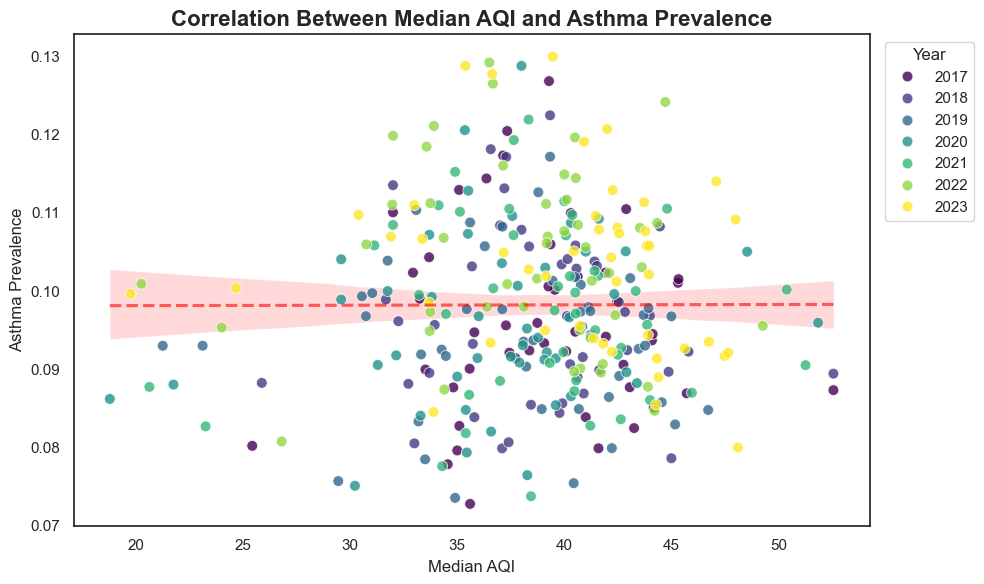

In [74]:
sns.set_theme(style="white")

plt.figure(figsize=(10, 6))

# Adding a trendline to look for correlation
sns.regplot(
    data = merged_state, 
    x = "Median AQI", 
    y = "asthma", 
    scatter = False, 
    color = 'red', 
    line_kws = {"linestyle": "--", "alpha": 0.6}
)

# Adding scatter points, colored by Year
sns.scatterplot(
    data = merged_state, 
    x = "Median AQI", 
    y = "asthma", 
    hue = "Year", 
    palette = "viridis",
    alpha = 0.8,
    s = 60 
)

plt.title("Correlation Between Median AQI and Asthma Prevalence", fontsize = 16, fontweight = 'bold')
plt.xlabel("Median AQI", fontsize = 12)
plt.ylabel("Asthma Prevalence", fontsize = 12)
plt.grid(False)

plt.legend(title = "Year", bbox_to_anchor = (1.01, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

The points form a cloud with no clear trend, there is no strong upward or downward slope. For the same AQI of around 40, asthma prevalence varies from ~0.08 to ~0.12. This suggestis that air quality alone does not strongly explain variations in asthma prevalence on the state level per year.

Let's do an experiment with time-lagging. It may be so that exposure to poor air quality might not instantly result in an asthma diagnosis within the same calendar year, but could manifest or worsen  the following year. To test this, we need to shift the data so that Year 1's AQI is aligned with Year 2's asthma prevalence for each specific state. We can do this in pandas using the .shift() function. 

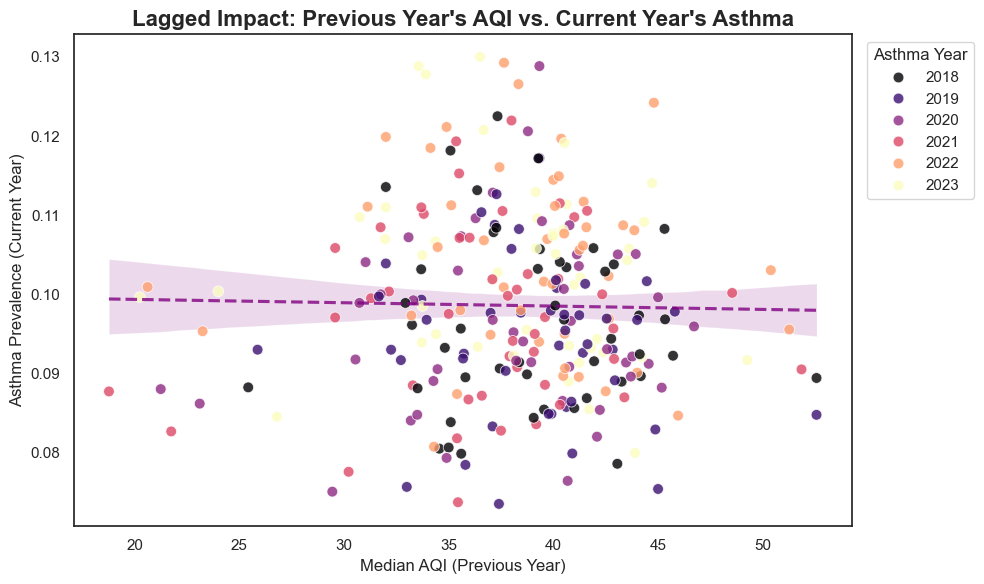

In [79]:
# Sorting the data to ensure years are in perfect order for each state
merged_state = merged_state.sort_values(by = ['State', 'Year'])

# Creating a new column: 'AQI_Previous_Year'
merged_state['AQI_Previous_Year'] = merged_state.groupby('State')['Median AQI'].shift(1)

#  Dropping empty rows (2017 does not have a "previous year")
lagged_data = merged_state.dropna(subset = ['AQI_Previous_Year', 'asthma'])

sns.set_theme(style = "white")
plt.figure(figsize = (10, 6))


sns.regplot(
    x = lagged_data['AQI_Previous_Year'], 
    y = lagged_data['asthma'], 
    scatter = False, 
    color = 'purple', 
    line_kws = {"linestyle": "--", "alpha": 0.8}
)

sns.scatterplot(
    x = lagged_data['AQI_Previous_Year'], 
    y = lagged_data['asthma'], 
    hue = lagged_data['Year'], 
    palette = "magma", 
    alpha = 0.8,
    s = 60 
)

plt.title("Lagged Impact: Previous Year's AQI vs. Current Year's Asthma", fontsize = 16, fontweight = 'bold')
plt.xlabel("Median AQI (Previous Year)", fontsize = 12)
plt.ylabel("Asthma Prevalence (Current Year)", fontsize = 12)
plt.grid(False)
plt.legend(title = "Asthma Year", bbox_to_anchor = (1.01, 1), loc = 'upper left')

plt.tight_layout()
plt.show()


Similarly as before, the experiment with time lagging also does not show any correlation.

Let's use boxplots to visualise the distribution of all states for each year. As Median AQI and Asthma prevalence are on completely different numerical scales, we will use subplots and will be able to compare the two variables despite their different scale.

C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\3669897154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\3669897154.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


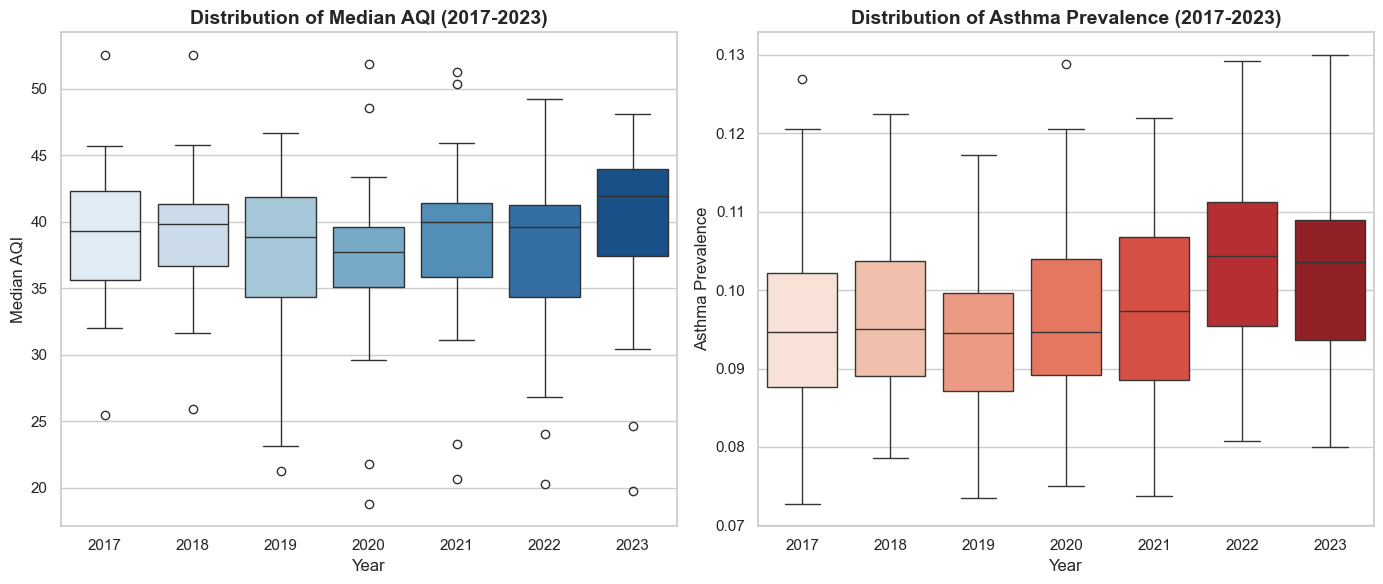

In [75]:
sns.set_theme(style = "whitegrid")

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# --- Plot 1: Median AQI Distribution over Time ---
sns.boxplot(
    data=merged_state, 
    x = "Year", 
    y = "Median AQI", 
    ax = axes[0],      
    palette = "Blues"  
)
axes[0].set_title("Distribution of Median AQI (2017-2023)", fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel("Year", fontsize = 12)
axes[0].set_ylabel("Median AQI", fontsize = 12)

# --- Plot 2: Asthma Prevalence Distribution over Time ---
sns.boxplot(
    data = merged_state, 
    x = "Year", 
    y = "asthma", 
    ax = axes[1],
    palette = "Reds"
)
axes[1].set_title("Distribution of Asthma Prevalence (2017-2023)", fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel("Year", fontsize = 12)
axes[1].set_ylabel("Asthma Prevalence", fontsize = 12)

plt.tight_layout()
plt.show()

In the distribution of Median AQI we can see a dip of the median line in 2020 which probably corresponds to the Covid-19 lockdowns, taking into account also that the overall spread of the box is lower. In 2023, the entire box shifts dramatically upward, and the median jumps to its highest point in the 7-year span. This suggests a widespread, national air quality event in 2023 and could be connected the massive Canadian wildfires that blanketed much of the US in heavy smoke that year. 

For the asthma prevalence distibution we can see that from 2017 to 2019, the national median remains relatively flat at around 0.095 (9.5%). Starting in 2020 and really accelerating into 2022 and 2023, the median line goes up upward, reaching about 0.105 (10.5%). Not only is the median rising, but the entire "box" is shifting up. The lowest asthma rates (the bottom whiskers) in 2022/2023 are higher than the lowest rates in the earlier years. This indicates a systemic, national increase in asthma diagnoses or prevalence over this time period.
In 2020, AQI went down, but asthma began to creep up.

Comparing the two subplots we can see that in 2021 and 2022, AQI returned to "normal" stable levels, but asthma continued a sharp climb. While both happen to spike in 2023, the broader 7-year trend proves that the steady rise in asthma prevalence is happening independently of the year-to-year fluctuations in Median AQI.

Now let's check which states are the worst polluted and what pollutants play a role. In order to do that we will take the mean of the features for each state through 2017-2023 and show the top 10 most polluted states. We will again use Median AQI as the value that represents best the typical situation for each state.

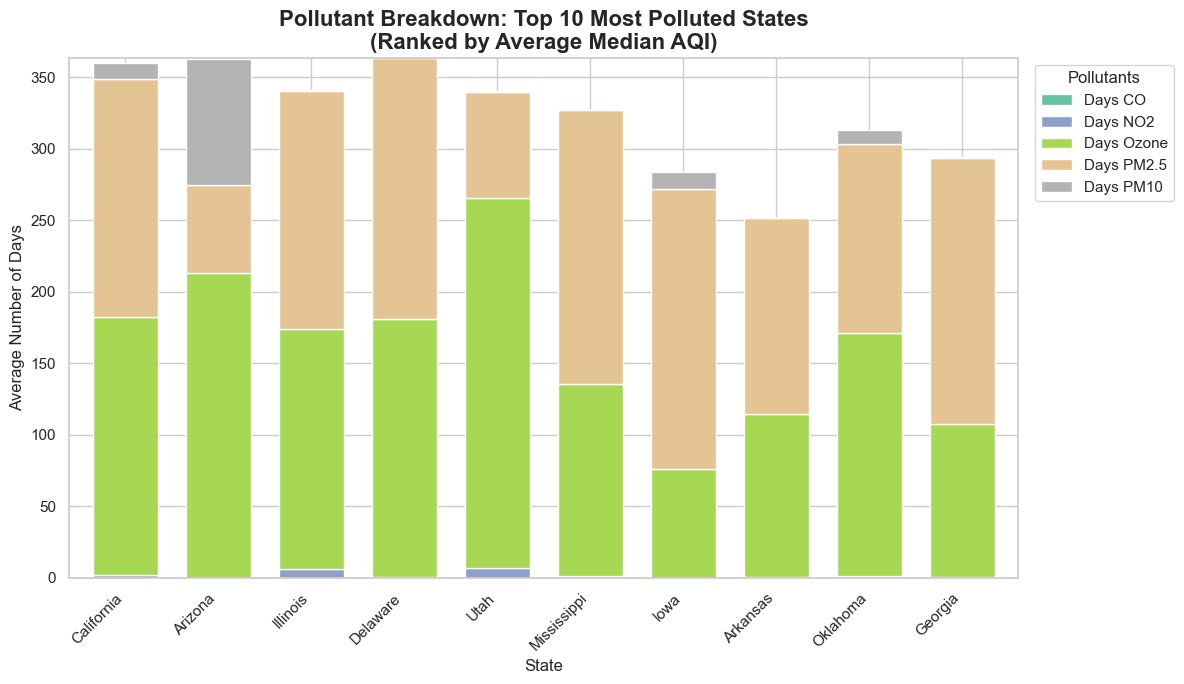

In [85]:
# Grouping by state to average out data
state_avg = merged_state.groupby('State').mean(numeric_only = True)

# Sorting by Median AQI to find the most polluted states, taking the top 10
top_polluted = state_avg.sort_values(by = 'Median AQI', ascending = False).head(10)

pollutants = ['Days CO', 'Days NO2', 'Days Ozone', 'Days PM2.5', 'Days PM10']
pollutant_data = top_polluted[pollutants]

sns.set_theme(style = "whitegrid")
fig, ax = plt.subplots(figsize = (12, 7))

pollutant_data.plot(kind = 'bar', stacked = True, ax = ax, width = 0.7, colormap = 'Set2')

ax.set_title('Pollutant Breakdown: Top 10 Most Polluted States\n(Ranked by Average Median AQI)', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Average Number of Days', fontsize = 12)
ax.set_xlabel('State', fontsize = 12)

plt.xticks(rotation = 45, ha = 'right') 
ax.legend(title = 'Pollutants', bbox_to_anchor = (1.01, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

Across almost all of the top 10 most polluted states, Ozone and PM2.5 completely dominate the chart. Utah and Arizona stand out for their extremely high number of Ozone days. Utah, in particular, sees Ozone as its primary pollutant for approximately 260 days out of the year on average.  Iowa has relatively low Ozone days, but it has a massive number of days where PM2.5 is the primary pollutant (nearly 200 days). Mississippi, Georgia, and Delaware also experience a very high volume of PM2.5-heavy days. Arizona also stands out with the high level of PM10 compared to other sates. In relaity, EPA has long designated the Phoenix-Mesa area as a "Serious" Nonattainment Area for PM10. This classification means the area fails to meet the federal National Ambient Air Quality Standards (NAAQS) for 24-hour PM10, which requires maximum reduction measures to be in place.

Let's see the same plot but only for 2023, to see what is the situation in the most recent year we have.

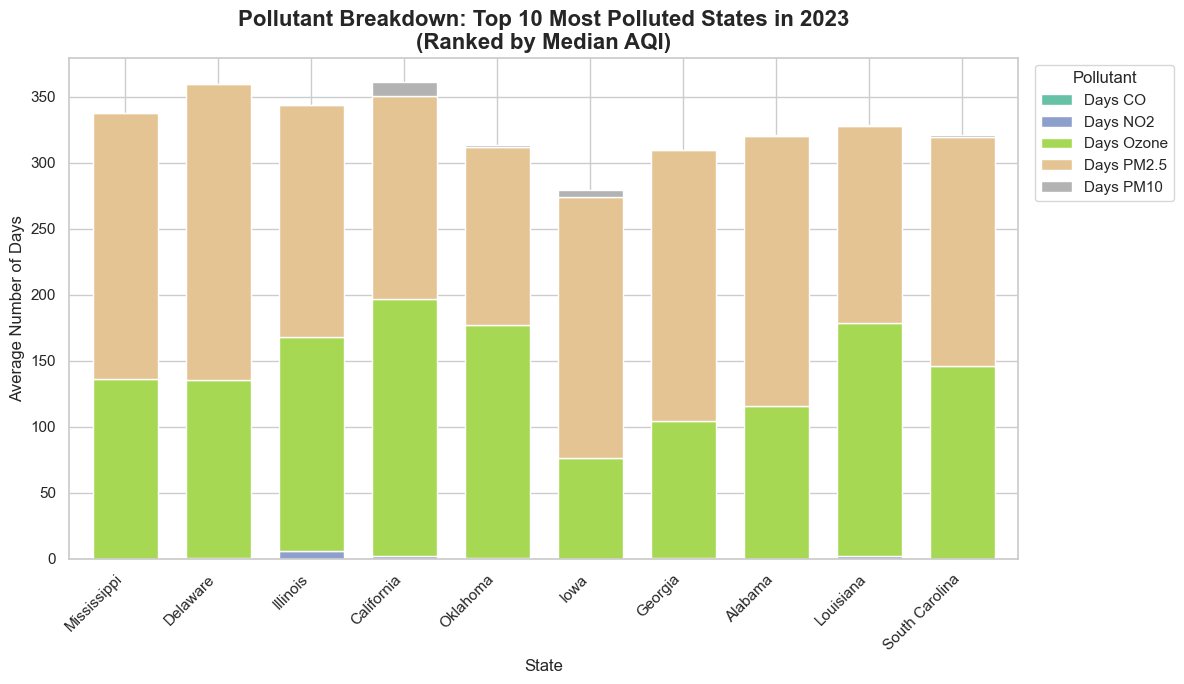

In [72]:
# Filtering and avaraging the data for only 2023
data_2023 = merged_state[merged_state['Year'] == 2023]
state_avg_2023 = data_2023.groupby('State').mean(numeric_only=True)

# Sorting by Median AQI to find the most polluted states, taking the top 10
top_polluted_2023 = state_avg_2023.sort_values(by='Median AQI', ascending=False).head(10)

pollutants = ['Days CO', 'Days NO2', 'Days Ozone', 'Days PM2.5', 'Days PM10']
pollutant_data_2023 = top_polluted_2023[pollutants]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize = (12, 7))

pollutant_data_2023.plot(kind = 'bar', stacked = True, ax = ax, width = 0.7, colormap = 'Set2')


ax.set_title('Pollutant Breakdown: Top 10 Most Polluted States in 2023\n(Ranked by Median AQI)', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Average Number of Days', fontsize = 12)
ax.set_xlabel('State', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right') 

ax.legend(title = 'Pollutant', bbox_to_anchor = (1.01, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

Most of the states with the highest polition are the same in 2023 again, except for three new.

Now let's explore the relantionship between Median AQI and Asthma prevalence in each of the most polluted states through the years. To overcome the difference in scale of the metrics, we will convert both AQI and Asthma to Z-scores, so we can put them on the exact same axis. 

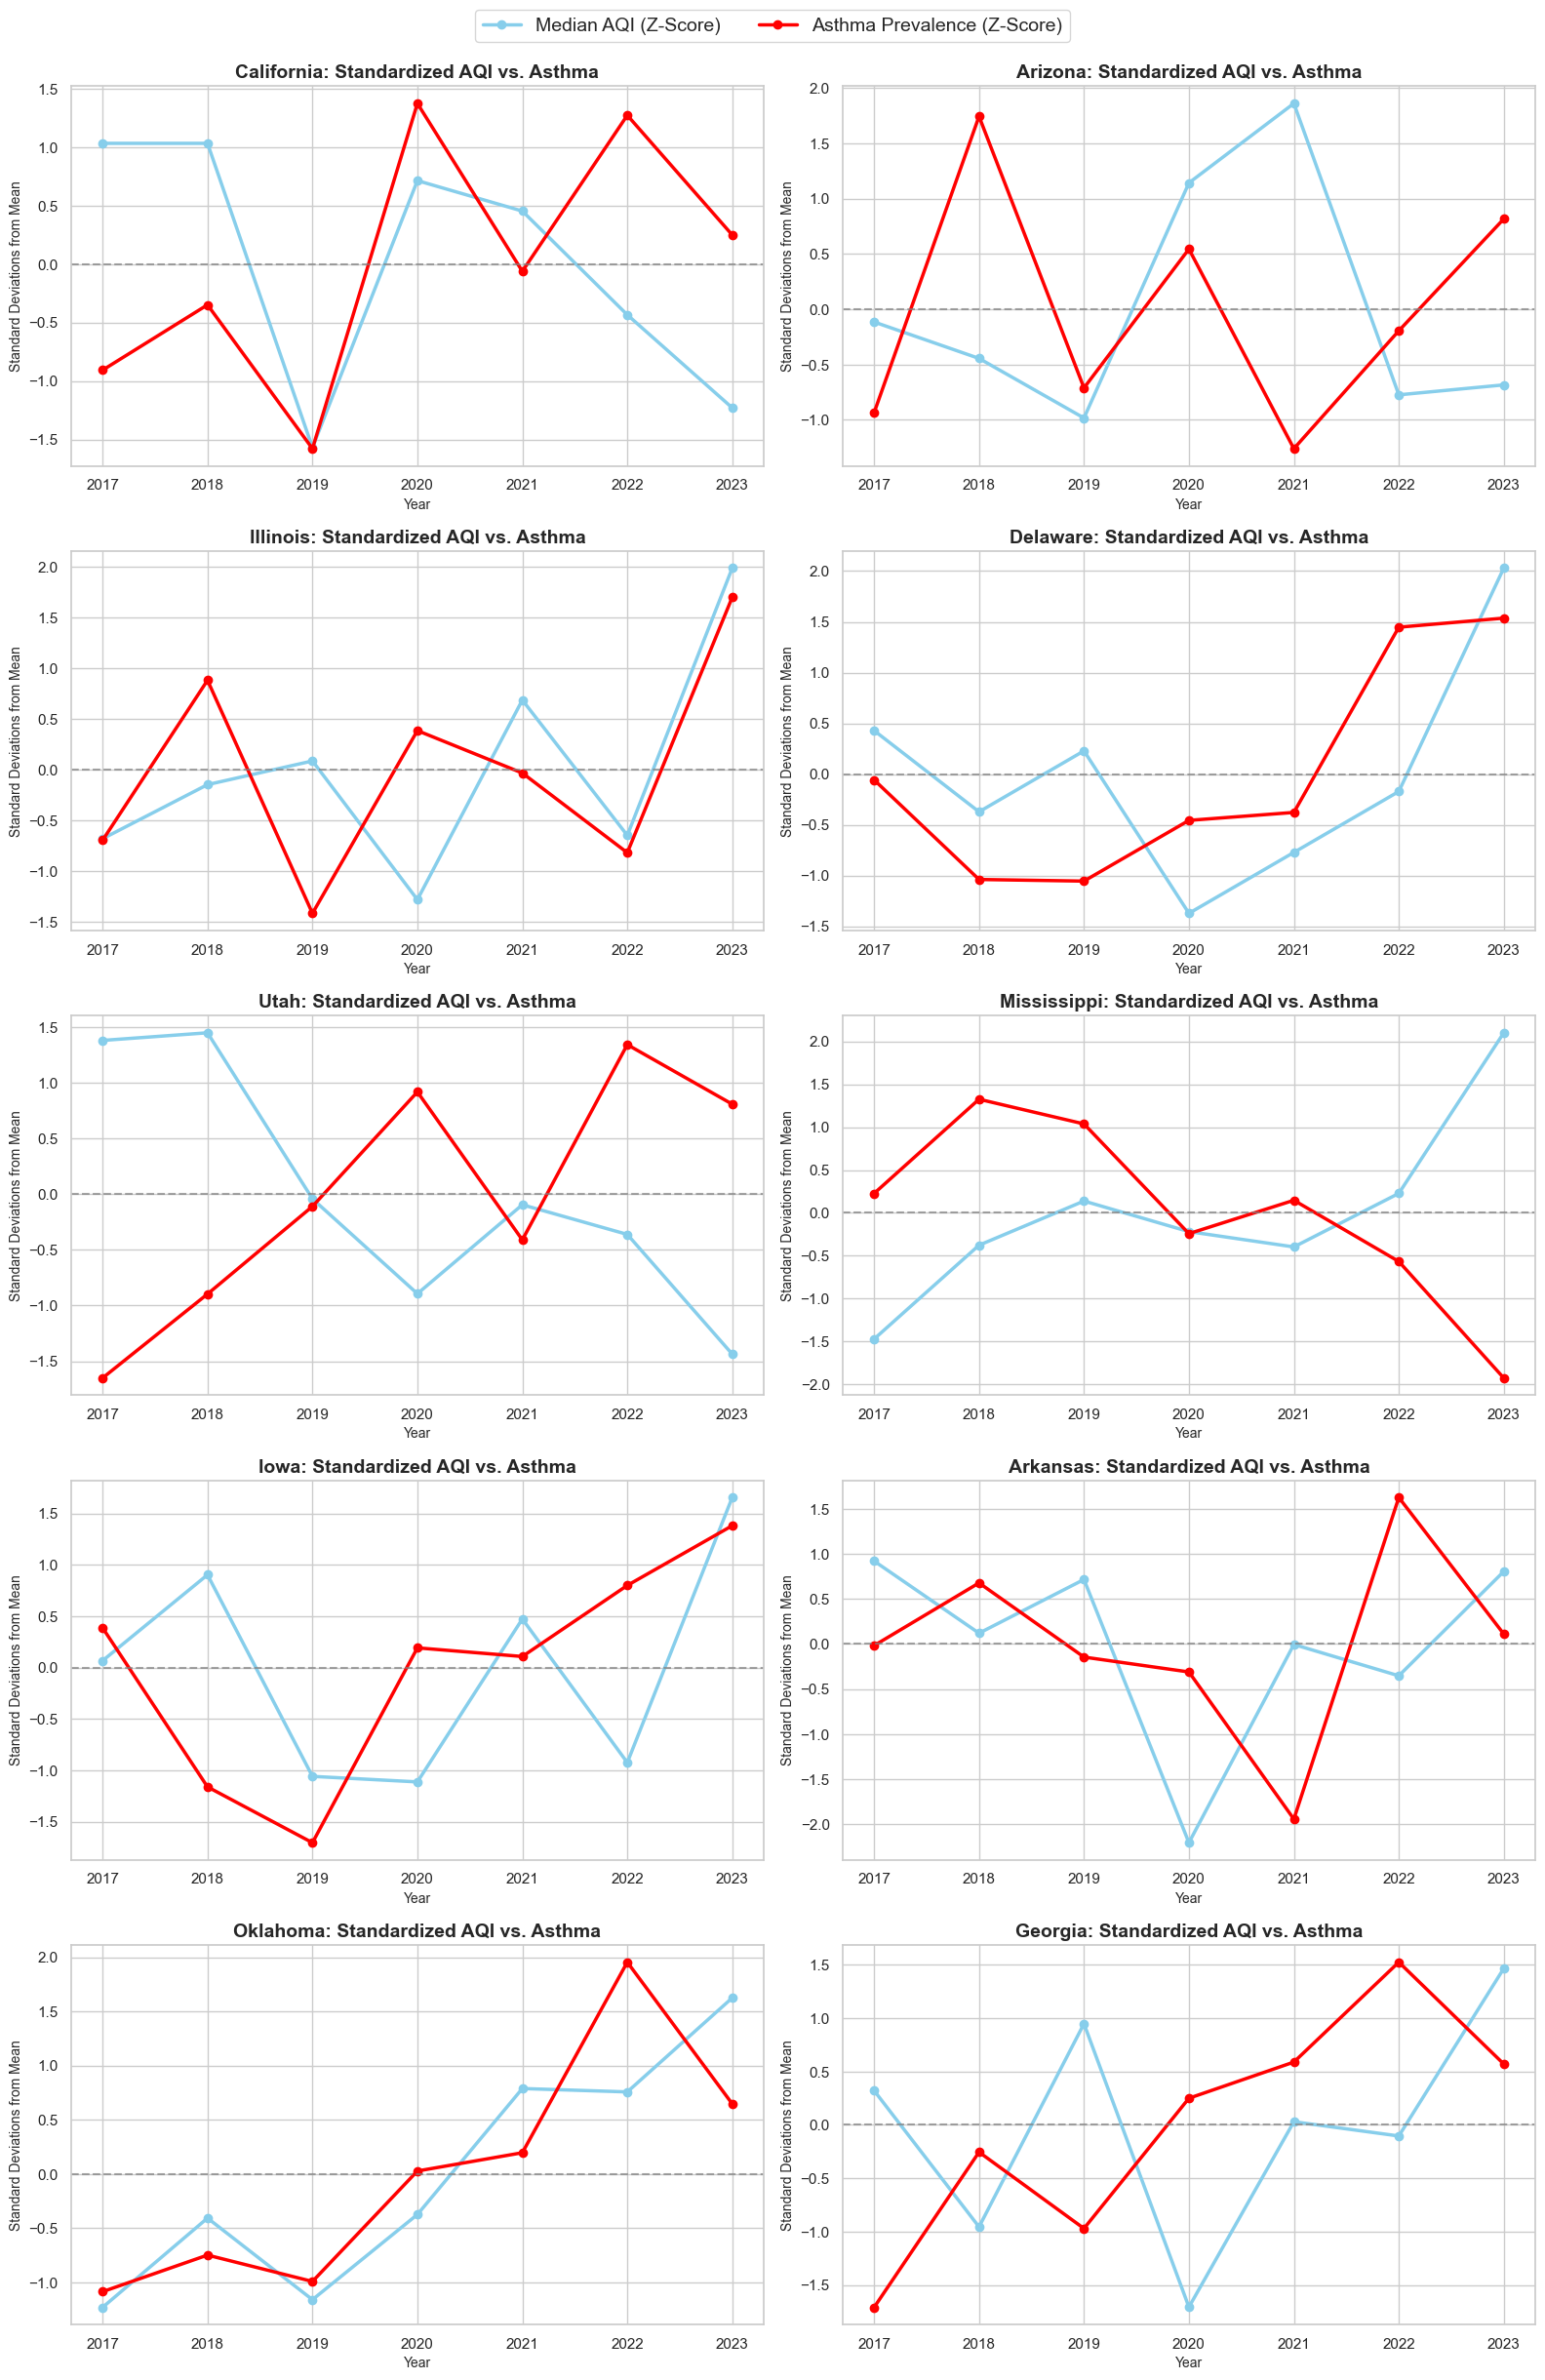

In [97]:
states_to_plot = top_polluted.index.tolist()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (16, 24))
axes = axes.flatten()

for i, state in enumerate(states_to_plot):
    state_data = merged_state[merged_state['State'] == state].sort_values('Year').copy()
    
    # Calculating Z-scores 
    state_data['AQI_Z'] = zscore(state_data['Median AQI'])
    state_data['Asthma_Z'] = zscore(state_data['asthma'])
    
    ax = axes[i]
    
    ax.plot(
        state_data['Year'].astype(str), 
        state_data['AQI_Z'], 
        color='skyblue', marker = 'o', linewidth = 2.5, label = 'Median AQI (Z-Score)'
    )
    ax.plot(
        state_data['Year'].astype(str), 
        state_data['Asthma_Z'], 
        color = 'red', marker = 'o', linewidth = 2.5, label = 'Asthma Prevalence (Z-Score)'
    )
    
    # Add a baseline at 0 which represents the exact average for that state
    ax.axhline(0, color = 'grey', linestyle = '--', alpha = 0.7)
    
    ax.set_title(f"{state}: Standardized AQI vs. Asthma", fontsize = 14, fontweight = 'bold')
    ax.set_ylabel("Standard Deviations from Mean", fontsize = 10)
    ax.set_xlabel("Year", fontsize = 10)

aqi_line = mlines.Line2D([], [], color = 'skyblue', marker = 'o', markersize = 6, linewidth = 2.5, label = 'Median AQI (Z-Score)')
asthma_line = mlines.Line2D([], [], color = 'red', marker = 'o', markersize = 6, linewidth = 2.5, label = 'Asthma Prevalence (Z-Score)')

fig.legend(
    handles = [aqi_line, asthma_line], 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.02), 
    ncol = 2, 
    fontsize = 14,
    frameon = True
)

plt.tight_layout()
plt.show()

Now let's check the correlations in figures.

In [98]:
states_to_plot = top_polluted.index.tolist()

state_correlations = {}

for state in states_to_plot:
    state_data = merged_state[merged_state['State'] == state]
    
    # Calculating the Pearson correlation between AQI and asthma
    corr = state_data['Median AQI'].corr(state_data['asthma'])
    
    state_correlations[state] = corr

# Converting the dictionary to a clean pandas DataFrame and sorting it
corr_df = pd.DataFrame.from_dict(state_correlations, orient = 'index', columns = ['Correlation (AQI vs Asthma)'])
corr_df = corr_df.sort_values(by='Correlation (AQI vs Asthma)', ascending = False)

print("--- Pearson Correlation: Median AQI vs. Asthma (Top 10 Polluted States) ---")
print(corr_df)

--- Pearson Correlation: Median AQI vs. Asthma (Top 10 Polluted States) ---
             Correlation (AQI vs Asthma)
Oklahoma                        0.780963
Delaware                        0.558303
Illinois                        0.518100
Iowa                            0.309601
California                      0.181839
Arkansas                        0.024525
Georgia                        -0.137019
Arizona                        -0.299359
Mississippi                    -0.696069
Utah                           -0.856279


Oklahoma (0.78) shows a strong positive correlation. Delaware (0.55) and Illinois (0.51) show a moderate positive relationship. Looking at the list, the correlations are completely scattered from +0.78 all the way to -0.85. Because of this inconsistency from state to state, we can confidently conclude that state-wide Median AQI is an unreliable predictor of asthma prevalence.  

Now let's move away from Median AQI and explore any correlation with the "extremes", Max AQI and Unhealthy for Sensitive Groups Days. One single day with a massive, hazardous spike in air pollution (like from a wildfire) might trigger asthma symptoms. 

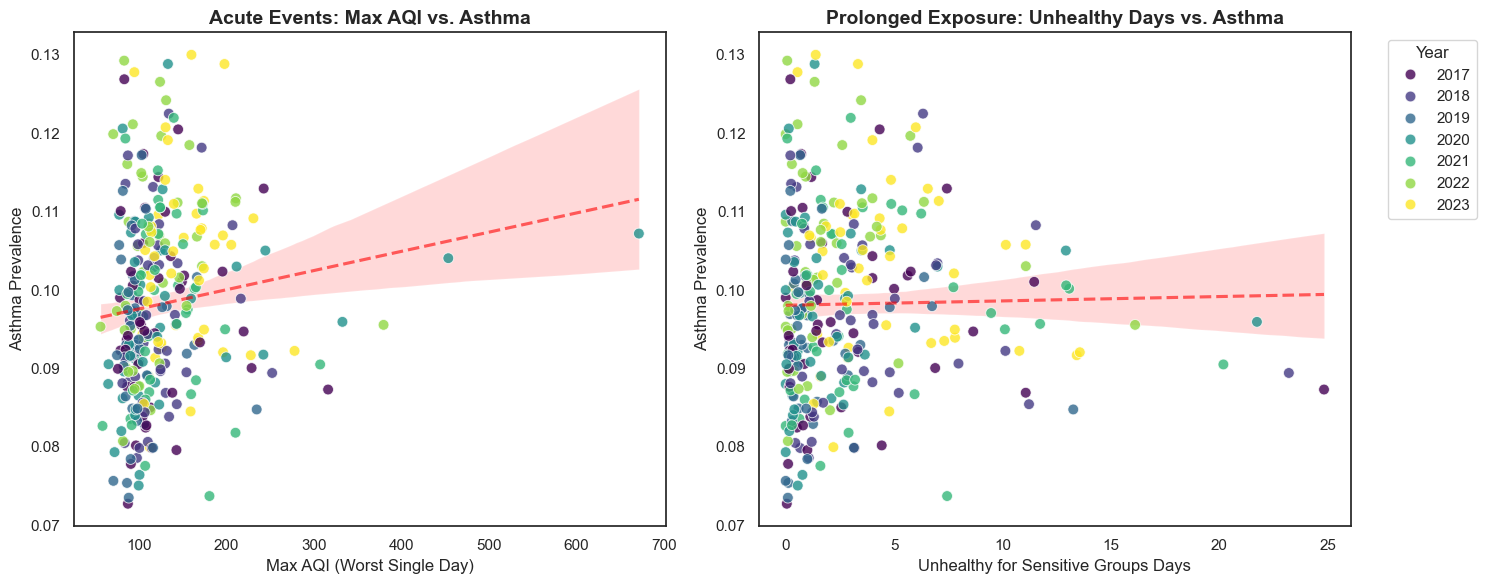

--- Pearson Correlation Coefficients ---
Max AQI vs Asthma: 0.1214
Unhealthy Days vs Asthma: 0.0181


In [84]:
sns.set_theme(style = "white")

fig, axes = plt.subplots(1, 2, figsize = (15, 6))

# --- Plot 1: Max AQI vs Asthma ---
sns.regplot(
    x = merged_state['Max AQI'], 
    y = merged_state['asthma'], 
    scatter = False, color = 'red', line_kws = {"linestyle": "--", "alpha": 0.6}, ax = axes[0]
)
sns.scatterplot(
    x = merged_state['Max AQI'], 
    y = merged_state['asthma'], 
    hue = merged_state['Year'], palette = "viridis", alpha = 0.8, s = 60, ax = axes[0]
)
axes[0].set_title("Acute Events: Max AQI vs. Asthma", fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel("Max AQI (Worst Single Day)", fontsize = 12)
axes[0].set_ylabel("Asthma Prevalence", fontsize = 12)
axes[0].grid(False)
axes[0].legend_.remove() 

# --- Plot 2: Unhealthy Days vs Asthma ---
sns.regplot(
    x = merged_state['Unhealthy for Sensitive Groups Days'], 
    y = merged_state['asthma'], 
    scatter = False, color = 'red', line_kws = {"linestyle": "--", "alpha": 0.6}, ax = axes[1]
)
sns.scatterplot(
    x = merged_state['Unhealthy for Sensitive Groups Days'], 
    y = merged_state['asthma'], 
    hue = merged_state['Year'], palette = "viridis", alpha = 0.8, s = 60, ax = axes[1]
)
axes[1].set_title("Prolonged Exposure: Unhealthy Days vs. Asthma", fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel("Unhealthy for Sensitive Groups Days", fontsize = 12)
axes[1].set_ylabel("Asthma Prevalence", fontsize = 12)
axes[1].grid(False)

axes[1].legend(title = "Year", bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.tight_layout()
plt.show()

# --- Calculate and Print the Exact Correlations ---
corr_max_aqi = merged_state['Max AQI'].corr(merged_state['asthma'])
corr_unhealthy = merged_state['Unhealthy for Sensitive Groups Days'].corr(merged_state['asthma'])

print("--- Pearson Correlation Coefficients ---")
print(f"Max AQI vs Asthma: {corr_max_aqi:.4f}")
print(f"Unhealthy Days vs Asthma: {corr_unhealthy:.4f}")

Although the line slopes up in the Max AQI subplot, a Pearson correlation of 0.12 is still a very weak positive correlation. For the longer exposure of Unhealthy Days, the correlation is non-existent.

Now let's run a Multiple Regression using a mix of the pollutant metrics to predict asthma. We will use the Ordinary Least Squares (OLS) Regression Model.

In [103]:
# Defining Independent Variables (The Predictors / X)
features = ['Max AQI', 'Unhealthy for Sensitive Groups Days', 'Days PM2.5', 'Days Ozone']

# Dropping any rows with missing data
model_data = merged_state.dropna(subset=features + ['asthma'])

X = model_data[features]
Y = model_data['asthma']

# Adding a constant to the model (This calculates the "Baseline" asthma rate if pollution was 0)
X = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) Regression Model
model = sm.OLS(Y, X).fit()

# 4. Print the professional statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 asthma   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     4.343
Date:                Fri, 08 May 2026   Prob (F-statistic):            0.00196
Time:                        18:45:41   Log-Likelihood:                 987.67
No. Observations:                 322   AIC:                            -1965.
Df Residuals:                     317   BIC:                            -1946.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

Combined air quality metrics explain only 5.2% of the variance in asthma rates (R-squared: 0.052), meaning that despite acute events like high ozone days or Max AQI having minor statistical significance, roughly 95% of state-wide asthma prevalence is driven by other factors. Looking at individual predictors, Days Ozone ($P=0.002$) and Max AQI ($P=0.010$) are the most reliable statistical drivers, whereas Unhealthy for Sensitive Groups Days ($P=0.062$) failed to reach significance. Despite these mathematical connections, the very small coefficients ($coef$) reveal that the real-world impact of these pollutants on the total percentage of asthma is minimal, and the warning about multicollinearity suggests that the pollutants often overlap, making it difficult for the model to isolate the effect of one from another. 

### Sources:
https://aafa.org/asthma/asthma-triggers-causes/air-pollution-smog-asthma/

https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/

https://www.nature.com/articles/s41598-025-88807-6

https://www.mdpi.com/2225-1154/13/2/23#B2-climate-13-00023

https://aqs.epa.gov/aqsweb/airdata/download_files.html

https://www.cdc.gov/brfss/annual_data/annual_data.htm

https://www.cdc.gov/brfss/annual_data/2023/pdf/2023-calculated-variables-version4-508.pdf

https://data.cdc.gov/

https://healthdata.gov/State/Asthma-Emergency-Department-Visit-Rates/28nb-65xq/about_data

https://us3.proxysite.com/process.php?d=7aUad2SQtxehj%2FpslPYLothCEh%2Buq24Ou07f0%2FC93NmAV8muq8dzD8DlN3XinTa2D2BXVSxwNF76UOD%2BRTw%3D&b=1

https://www.epa.gov/sites/default/files/2015-05/documents/az_deq_july_2011_pm10_ee_demo_final_20120308.pdf

